In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
# Create a random dataset
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))


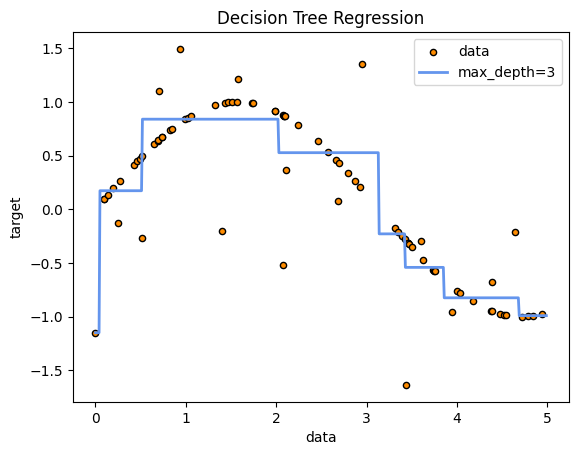

In [ ]:
# Fit regression model(depth = 2, node = 4)
#  As the number of nodes increases, the accuracy increases. If it is too large, overfit occurs
regr_1 = DecisionTreeRegressor(max_depth=3) # Tree Node: 2**max_depth = 8
regr_1.fit(X, y)

# Predict
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)

# Plot the results
plt.figure()
plt.scatter(X, y, s=20, edgecolor="black",
c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue",
label="max_depth=3", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

In [ ]:
ㄴ

0.0

In [1]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
print(data.data.shape)

(20640, 8)


In [ ]:
data.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [2]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

(array([ 877., 3612., 4099., 3771., 2799., 1769., 1239.,  752.,  479.,
        1243.]),
 array([0.14999 , 0.634992, 1.119994, 1.604996, 2.089998, 2.575   ,
        3.060002, 3.545004, 4.030006, 4.515008, 5.00001 ]),
 <BarContainer object of 10 artists>)

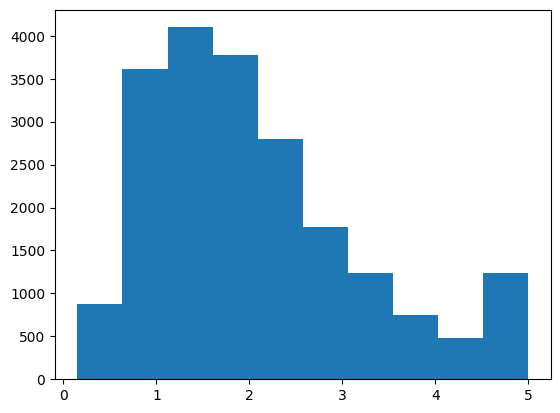

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.hist(data.target)

{'whiskers': [<matplotlib.lines.Line2D at 0x7e00b412e3b0>,
 'caps': [<matplotlib.lines.Line2D at 0x7e00b412e200>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e00b412ecb0>],
 'medians': [<matplotlib.lines.Line2D at 0x7e00b412c9d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e00b412c9a0>],
 'means': []}

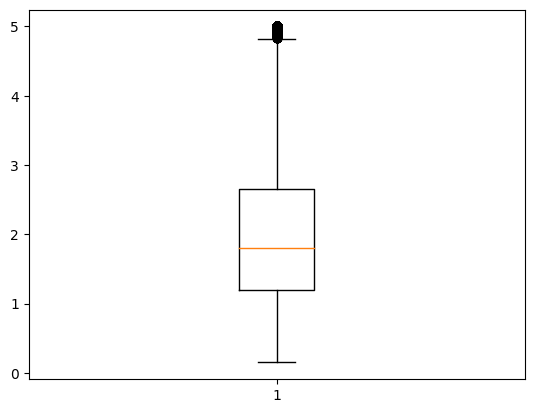

In [ ]:
plt.boxplot(data.target)

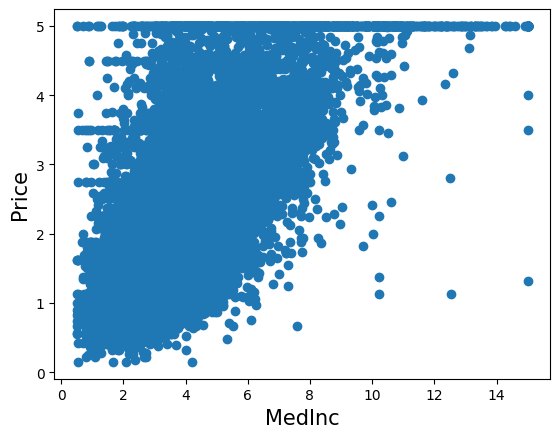

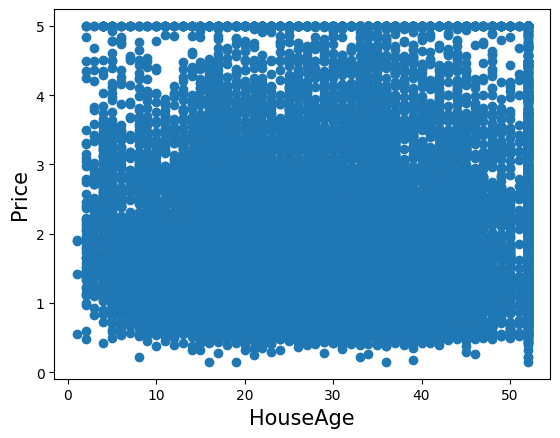

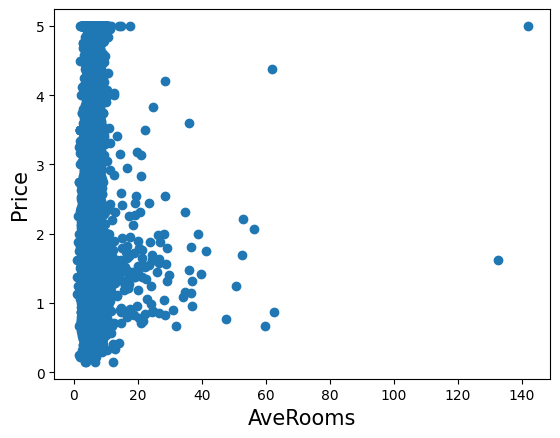

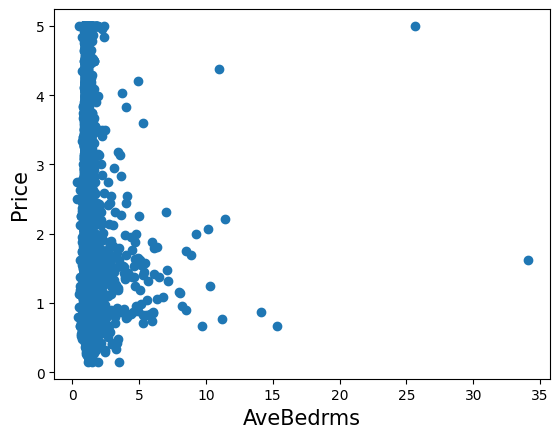

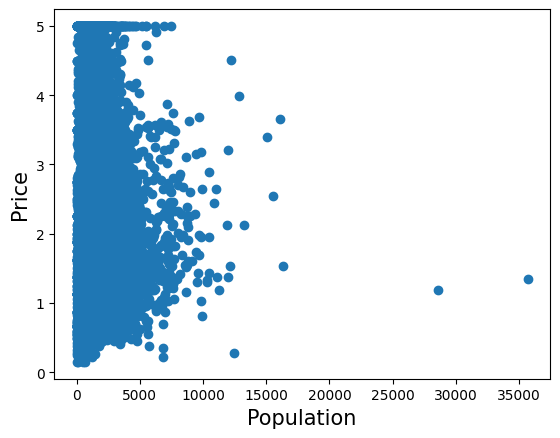

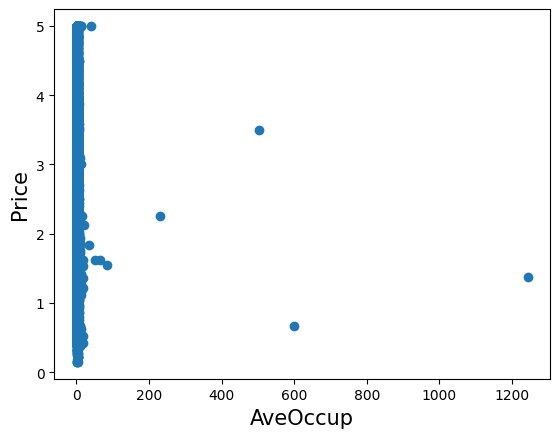

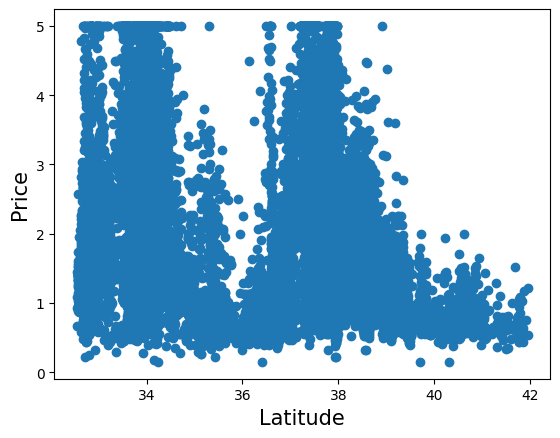

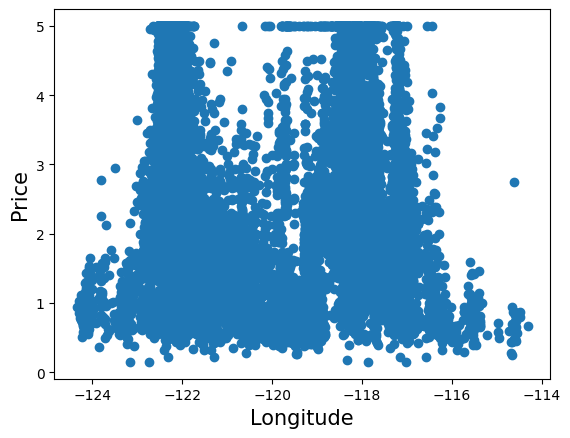

In [ ]:
for index, feature_name in enumerate(data.feature_names):
    plt.figure()
    plt.scatter(data.data[:, index], data.target)
    plt.ylabel('Price', size=15)
    plt.xlabel(feature_name, size=15)

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target)
from sklearn.linear_model import LinearRegression
import numpy as np
clf = LinearRegression()
clf.fit(X_train, y_train)
predicted = clf.predict(X_test)
expected = y_test
print("RMS: %s " % np.sqrt(np.mean((predicted - expected) ** 2)))

RMS: 0.7342754202586657 


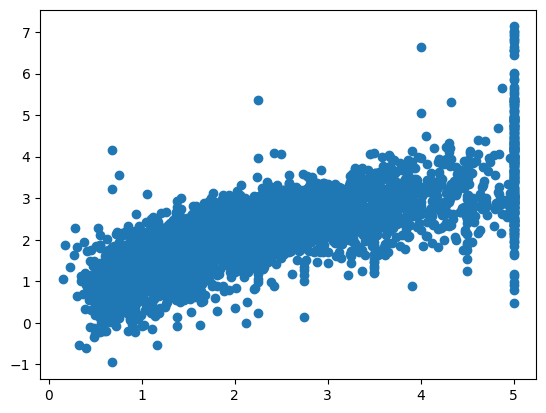

In [5]:
plt.scatter(expected, predicted)

In [ ]:
clf.coef_, clf.intercept_

(array([ 4.36216544e-01,  9.95433549e-03, -1.04748213e-01,  6.32635347e-01,
        -2.94745049e-06, -3.35236475e-03, -4.17160475e-01, -4.30371932e-01]),
 -36.6046724145599)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
regr = DecisionTreeRegressor(max_depth=9)
regr.fit(X_train, y_train)
predicted = regr.predict(X_test)
expected = y_test
print("RMS: %s " % np.sqrt(np.mean((predicted - expected) ** 2)))

RMS: 0.6559095307566551 


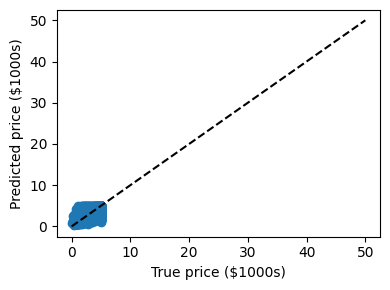

In [7]:
plt.figure(figsize=(4, 3))
plt.scatter(expected, predicted)
plt.plot([0, 50], [0, 50], '--k')
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')
plt.tight_layout()

In [ ]:
!pip install pydotplus
import pydotplus
from PIL import Image
from sklearn.tree import export_graphviz
dot_data = export_graphviz(regr, feature_names=data.feature_names,out_file=None)
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png("tree.png")

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.37094 to fit



True

In [ ]:
!ls tree.png

tree.png


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
import matplotlib.pyplot as plt
regr1 = DecisionTreeRegressor(max_depth=10)
regr2 = AdaBoostRegressor(DecisionTreeRegressor(max_depth=10), n_estimators=300)
regr1.fit(X_train, y_train)
regr2.fit(X_train, y_train)
predicted1 = regr1.predict(X_test)
predicted2 = regr2.predict(X_test)
expected = y_test
print("RMS: %s " % np.sqrt(np.mean((predicted1 - expected) ** 2)))
print("RMS: %s " % np.sqrt(np.mean((predicted2 - expected) ** 2)))

RMS: 0.6609480438277602 
RMS: 0.5092265275816185 


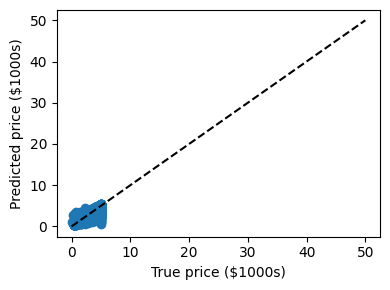

In [10]:
from sklearn.ensemble import GradientBoostingRegressor
clf = GradientBoostingRegressor()
clf.fit(X_train, y_train)
predicted = clf.predict(X_test)
expected = y_test
plt.figure(figsize=(4, 3))
plt.scatter(expected, predicted)
plt.plot([0, 50], [0, 50], '--k')
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')
plt.tight_layout()

In [11]:
predicted3 = clf.predict(X_test)
expected = y_test
print("RMS: %s " % np.sqrt(np.mean((predicted3 - expected) ** 2)))

RMS: 0.5395520059418074 


In [12]:
import xgboost as xgb
xg_reg = xgb.XGBRegressor(objective ='reg:linear', colsample_bytree = 0.5, learning_rate = 0.1,
                max_depth = 5, alpha = 10, n_estimators = 300)

# colsample_bytree: 각 트리의 feature sampling 비율로 0.5는 50%의 feature 만 사용
# alpha는 Ridge Regression 조절모수

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [11:04:53] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


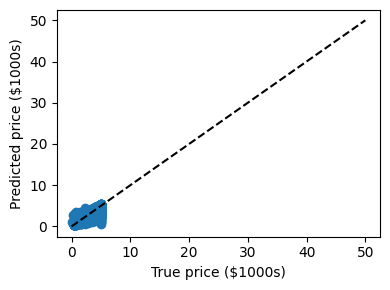

In [13]:
xg_reg.fit(X_train, y_train)
predicted = clf.predict(X_test)
expected = y_test
plt.figure(figsize=(4, 3))
plt.scatter(expected, predicted)
plt.plot([0, 50], [0, 50], '--k')
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')
plt.tight_layout()

In [14]:
predicted = xg_reg.predict(X_test)
expected = y_test
print("RMS: %s " % np.sqrt(np.mean((predicted - expected) ** 2)))

RMS: 0.4701495005853981 


In [15]:
import lightgbm as lgb
lgb_reg = lgb.LGBMRegressor(objectuve='regression', num_leaves = 7, learning_rate = 0.1, n_estimators = 300)

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


[LightGBM] [Warning] Unknown parameter: objectuve
[LightGBM] [Warning] Unknown parameter: objectuve
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002766 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 15480, number of used features: 8
[LightGBM] [Info] Start training from score 2.070491
[LightGBM] [Warning] Unknown parameter: objectuve


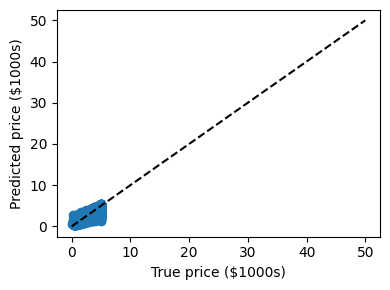

In [16]:
lgb_reg.fit(X_train, y_train)
predicted = lgb_reg.predict(X_test)
expected = y_test
plt.figure(figsize=(4, 3))
plt.scatter(expected, predicted)
plt.plot([0, 50], [0, 50], '--k')
plt.axis('tight')
plt.xlabel('True price ($1000s)')
plt.ylabel('Predicted price ($1000s)')
plt.tight_layout()

In [17]:
predicted = lgb_reg.predict(X_test)
expected = y_test
print("RMS: %s " % np.sqrt(np.mean((predicted - expected) ** 2)))

[LightGBM] [Warning] Unknown parameter: objectuve
RMS: 0.48579773660892894 


In [18]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
clf = LGBMRegressor()
param_grid = {
    'num_leaves': [5, 6, 7, 8, 9, 31],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'learning rate': [0.1, 0.001, 0.003]
}
gsearch = GridSearchCV(estimator=clf, param_grid=param_grid)
gsearch.fit(X_train, y_train)


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[LightGBM] [Warning] Unknown parameter: learning
[LightGBM] [Warning] Unknown parameter: rate
[LightGBM] [Warning] Unknown parameter: learning
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 12384, number of used features: 8
[LightGBM] [Info] Start training from score 2.066818
[LightGBM] [Warning] Unknown parameter: rate
[LightGBM] [Warning] Unknown parameter: learning
[LightGBM] [Warning] Unknown parameter: rate
[LightGBM] [Warning] Unknown parameter: learning
[LightGBM] [Warning] Unknown parameter: rate
[LightGBM] [Warning] Unknown parameter: learning
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001386 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[L

GridSearchCV(estimator=LGBMRegressor(),
             param_grid={'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                         'learning rate': [0.1, 0.001, 0.003],
                         'num_leaves': [5, 6, 7, 8, 9, 31]})

In [19]:
gsearch.best_params_

{'colsample_bytree': 0.7, 'learning rate': 0.1, 'num_leaves': 31}

In [20]:
predicted = gsearch.predict(X_test)
expected = y_test
print("RMS: %s " % np.sqrt(np.mean((predicted - expected) ** 2)))

[LightGBM] [Warning] Unknown parameter: rate
[LightGBM] [Warning] Unknown parameter: learning
RMS: 0.4671059608115477 
